In [12]:
# Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Load Prepared Data

df = pd.read_csv('prepared_data.csv')

# Target
y = df['SalePrice']

# Features — drop target and useless columns
X = df.drop(columns=[
    'SalePrice',
    'SalePrice_log',
    'Order',
    'PID'
], errors='ignore')

# Safety check
if 'SalePrice_log' in X.columns:
    print("WARNING: Data leakage detected! Dropping SalePrice_log...")
    X = X.drop('SalePrice_log', axis=1)
else:
    print("Good! No data leakage.")

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Good! No data leakage.
Features shape : (2793, 252)
Target shape   : (2793,)


In [14]:
# Split data into Train & Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (2234, 252)
Test size : (559, 252)


In [17]:
#  Helper function to evaluate models

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE : ${rmse:,.0f}")
    print(f"  MAE  : ${mae:,.0f}")
    print(f"  R²   : {r2:.4f}")

    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Predictions': y_pred}

In [18]:
# Train and evaluate all 3 models

lr  = evaluate_model("Linear Regression",
                     LinearRegression(),
                     X_train, X_test, y_train, y_test)

rf  = evaluate_model("Random Forest",
                     RandomForestRegressor(random_state=42),
                     X_train, X_test, y_train, y_test)

xgb = evaluate_model("XGBoost",
                     XGBRegressor(random_state=42, verbosity=0),
                     X_train, X_test, y_train, y_test)

results = [lr, rf, xgb]


  Linear Regression
  RMSE : $33,658
  MAE  : $14,241
  R²   : 0.6954

  Random Forest
  RMSE : $20,022
  MAE  : $13,921
  R²   : 0.8922

  XGBoost
  RMSE : $18,608
  MAE  : $12,836
  R²   : 0.9069


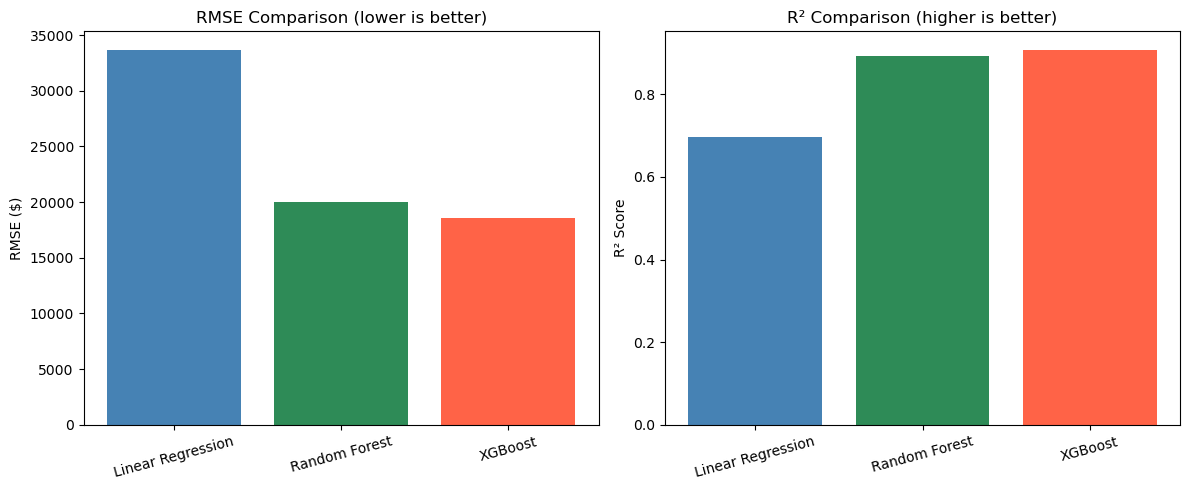

In [19]:
# Compare models in a bar chart

compare_df = pd.DataFrame([{
    'Model': r['Model'],
    'RMSE' : r['RMSE'],
    'R2'   : r['R2']
} for r in results])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(compare_df['Model'], compare_df['RMSE'],
            color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(compare_df['Model'], compare_df['R2'],
            color=['steelblue', 'seagreen', 'tomato'])
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

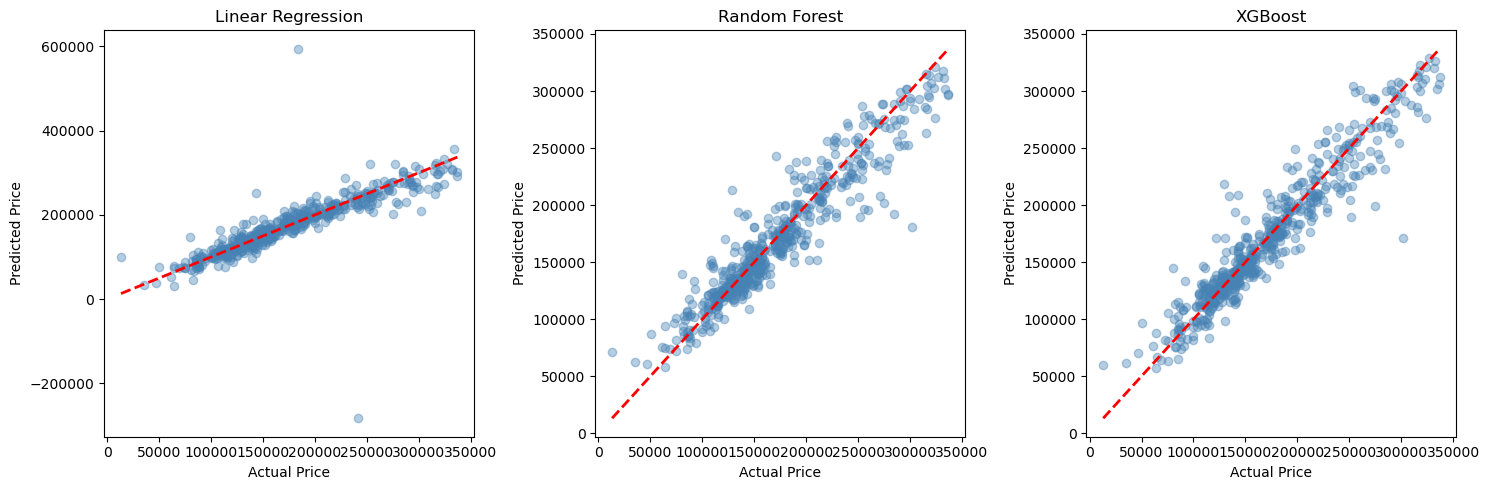

In [20]:
# Actual vs Predicted plot for all 3 model

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, result in enumerate(results):
    axes[i].scatter(y_test, result['Predictions'], alpha=0.4, color='steelblue')
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(result['Model'])
    axes[i].set_xlabel('Actual Price')
    axes[i].set_ylabel('Predicted Price')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

In [21]:
# summery table
summary = pd.DataFrame([{
    'Model': r['Model'],
    'RMSE' : f"${r['RMSE']:,.0f}",
    'MAE'  : f"${r['MAE']:,.0f}",
    'R²'   : f"{r['R2']:.4f}"
} for r in results])

print("\n===== Model Comparison Summary =====")
print(summary.to_string(index=False))


===== Model Comparison Summary =====
            Model    RMSE     MAE     R²
Linear Regression $33,658 $14,241 0.6954
    Random Forest $20,022 $13,921 0.8922
          XGBoost $18,608 $12,836 0.9069
